# Exploration du Framework Quant : Régimes, Stratégies & Backtests

Ce notebook montre, de bout en bout :

- Chargement des données
- Détection et visualisation des **régimes de marché**
- Scanner d’un marché avec `analyze_single_market`
- Application de plusieurs **stratégies** (EMA, RSI)
- Backtests avec `execute_trades` et `extract_trades`
- Calcul et affichage des **métriques complètes** via `compute_all_metrics`
- Comparaison visuelle des stratégies


In [17]:
# Cellule 1 — Imports principaux

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_loader import load_data

from regimes import (
    volatility_regime,
    trend_regime,
    range_regime,
    impulse_regime,
)

from market_scanner import analyze_single_market

from strategies.ema_cross import ema_cross_strategy
from strategies.rsi_strategies import (
    rsi_reversion_strategy,
    rsi_overreaction_strategy,
)

from backtest_py.backtest import execute_trades, extract_trades
from backtest_py.metrics import compute_all_metrics

plt.style.use("seaborn-v0_8")


## 1. Paramètres globaux


In [18]:
# Cellule 2 — Paramètres globaux

TICKER = "AAPL"
START = "2015-01-01"
END = None  # ou "2024-12-31"

BACKTEST_PARAMS = {
    "initial_capital": 10000,
    "fee": 0.0001,
    "slippage": 0.0002,
    "quantity": 1,
}


## 2. Chargement des données & aperçu


In [19]:
# Cellule 3 — Chargement des données

df = load_data(TICKER, start=START, end=END)
print(df.shape)
df.head()


Les données sont  MultiIndex, correction en cours...
✅ Données pour AAPL chargées avec succès après 1 tentatives.
(2842, 5)


Price,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,24.671153,24.682228,23.776355,24.214895,212818400
2015-01-05,23.984551,24.064285,23.346676,23.532722,257142000
2015-01-06,23.596948,23.794069,23.173912,23.534933,263188400
2015-01-07,23.743127,23.964612,23.632385,23.864944,160423600
2015-01-08,24.192745,24.839479,24.075357,24.781893,237458000


## 3. Régimes de marché : calcul


In [20]:
# Cellule 4 — Calcul des régimes

vol = volatility_regime(df)
trend = trend_regime(df)
rng = range_regime(df)
imp = impulse_regime(df)

regimes = pd.DataFrame(index=df.index)
regimes["volatility"] = vol["regime"]
regimes["trend"] = trend["regime"]
regimes["range"] = rng["regime"]
regimes["impulse"] = imp["regime"]

regimes.tail()


,volatility,trend,range,impulse
Date,,,,
2026-04-16,normal,downtrend,not_range,normal
2026-04-17,normal,neutral,not_range,impulse_up
2026-04-20,normal,neutral,not_range,normal
2026-04-21,normal,neutral,not_range,normal
2026-04-22,normal,downtrend,not_range,normal


## 4. Visualisation du prix + régime de tendance (fond coloré)

- Vert : tendance haussière
- Rouge : tendance baissière
- Transparent : neutre


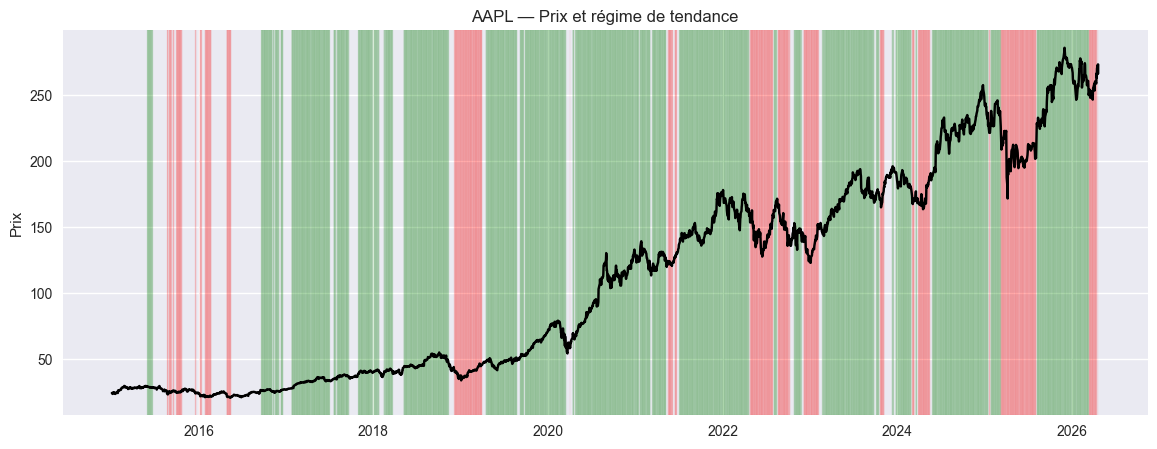

In [ ]:
# Cellule 5 — Prix + tendance avec fond coloré (vert= merché haussier
# Rouge = marché haussier, blanc = marché sans tendance claire)

fig, ax = plt.subplots(figsize=(14, 5))

# Prix
ax.plot(df.index, df["Close"], color="black", label="Prix de clôture")
ax.set_title(f"{TICKER} — Prix et régime de tendance")
ax.set_ylabel("Prix")

# Coloration des régimes
for i in range(1, len(df)):
    regime_today = trend["regime"].iloc[i]
    t0 = df.index[i-1]
    t1 = df.index[i]

    if regime_today == "uptrend":
        ax.axvspan(t0, t1, color="green", alpha=0.15)
    elif regime_today == "downtrend":
        ax.axvspan(t0, t1, color="red", alpha=0.15)
    # neutral : pas de couleur

plt.show()


## 5. Visualisation des autres régimes

On affiche :

- Volatilité (low / normal / high)
- Range (range / not_range)
- Impulsion (impulse_up / impulse_down / normal)


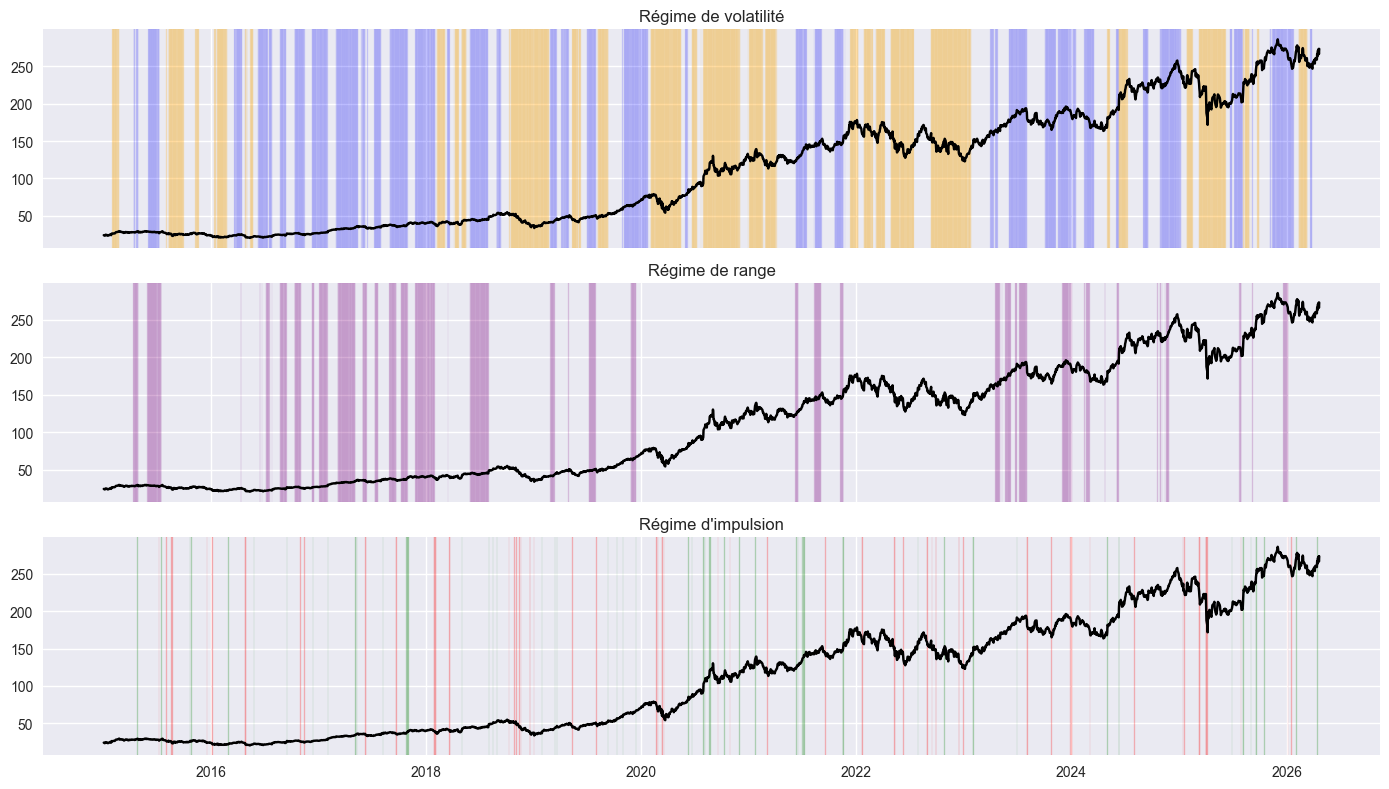

In [22]:
# Cellule 6 — Visualisation des régimes (volatilité, range, impulsion)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# 1) Volatilité
axes[0].plot(df.index, df["Close"], color="black")
axes[0].set_title("Régime de volatilité")

for i in range(1, len(df)):
    reg = vol["regime"].iloc[i]
    t0, t1 = df.index[i-1], df.index[i]
    if reg == "low_vol":
        axes[0].axvspan(t0, t1, color="blue", alpha=0.12)
    elif reg == "high_vol":
        axes[0].axvspan(t0, t1, color="orange", alpha=0.18)

# 2) Range
axes[1].plot(df.index, df["Close"], color="black")
axes[1].set_title("Régime de range")

for i in range(1, len(df)):
    reg = rng["regime"].iloc[i]
    t0, t1 = df.index[i-1], df.index[i]
    if reg == "range":
        axes[1].axvspan(t0, t1, color="purple", alpha=0.15)

# 3) Impulsion
axes[2].plot(df.index, df["Close"], color="black")
axes[2].set_title("Régime d'impulsion")

for i in range(1, len(df)):
    reg = imp["regime"].iloc[i]
    t0, t1 = df.index[i-1], df.index[i]
    if reg == "impulse_up":
        axes[2].axvspan(t0, t1, color="green", alpha=0.2)
    elif reg == "impulse_down":
        axes[2].axvspan(t0, t1, color="red", alpha=0.2)

plt.tight_layout()
plt.show()


## 6. Analyse d’un marché avec `analyze_single_market`


In [23]:
# Cellule 7 — Analyse d’un marché

analysis = analyze_single_market(df)
analysis


{'volatility': 'normal',
 'trend': 'downtrend',
 'range': 'not_range',
 'impulse': 'normal',
 'trend_up_start': False,
 'trend_down_start': True,
 'impulse_up': False,
 'impulse_down': False,
 'low_vol': False,
 'high_vol': False,
 'summary': 'début de tendance baissière'}

## 7. Application des stratégies

On va appliquer :

- `ema_cross_strategy`
- `rsi_reversion_strategy`
- `rsi_overreaction_strategy`

Pipeline pour chaque stratégie :

1. Générer le signal
2. Exécuter les trades → equity curve
3. Extraire les trades
4. Calculer les métriques complètes
5. Visualiser l’equity curve


In [24]:
# Cellule 8 — Fonction utilitaire pour backtester une stratégie

def run_strategy(df, signal_func, params, name: str, **signal_kwargs):
    """
    df : DataFrame OHLCV
    signal_func : fonction de stratégie qui renvoie une Series 'signal'
    params : dict pour execute_trades / extract_trades
    name : nom de la stratégie (pour les titres)
    signal_kwargs : paramètres de la stratégie
    """
    signal = signal_func(df, **signal_kwargs)
    equity = execute_trades(df, signal, params)
    trades = extract_trades(df, signal, params)
    metrics = compute_all_metrics(equity, trades)

    return {
        "name": name,
        "signal": signal,
        "equity": equity,
        "trades": trades,
        "metrics": metrics,
    }


## 8. Backtest de la stratégie EMA Cross


In [25]:
# Cellule 9 — EMA Cross

res_ema = run_strategy(
    df,
    ema_cross_strategy,
    BACKTEST_PARAMS,
    name="EMA Cross 12/26",
    fast=12,
    slow=26,
    atr_period=14,
    atr_multiplier=2.0,
)

res_ema["trades"].head()


c:\Finance\Projet maîtrise klosalo\strategies\ema_cross.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if ema_fast[i] > ema_slow[i] and ema_fast[i - 1] <= ema_slow[i - 1]:
c:\Finance\Projet maîtrise klosalo\strategies\ema_cross.py:30: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif ema_fast[i] < ema_slow[i] and ema_fast[i - 1] >= ema_slow[i - 1]:
c:\Finance\Projet maîtrise klosalo\strategies\ema_cross.py:45: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by posi

,entry_date,entry_price,exit_date,exit_price,pnl,return_trade,duration,direction
0,2015-06-15,28.150907,2015-07-23,28.184497,-0.039223,-0.001393,38 days,short
1,2015-07-27,27.478940,2018-03-27,40.810257,-13.338146,-0.485395,974 days,short
2,2018-04-17,41.470538,2018-04-23,39.185000,-2.293604,-0.055307,6 days,long
3,2018-04-24,38.912545,2018-05-03,41.327214,-2.422692,-0.062260,9 days,short
4,2018-05-07,43.512458,2020-10-02,109.579287,66.051519,1.517991,879 days,long


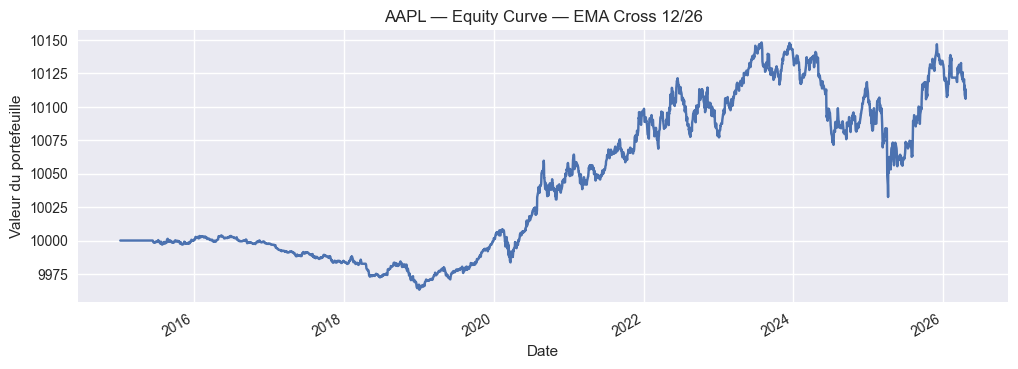

In [26]:
# Cellule 10 — Equity curve EMA

res_ema["equity"].plot(figsize=(12, 4), title=f"{TICKER} — Equity Curve — {res_ema['name']}")
plt.ylabel("Valeur du portefeuille")
plt.show()


In [27]:
# Cellule 11 — Métriques EMA

pd.DataFrame(res_ema["metrics"], index=[res_ema["name"]])


,total_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,num_trades,win_rate,profit_factor,avg_win,avg_loss,expectancy,avg_duration
EMA Cross 12/26,0.010621,0.000938,0.003603,0.260208,0.314136,-0.011389,0.082327,16,0.5,2.958276,29.006168,-9.805093,9.600537,239 days 10:30:00


## 9. Backtest des stratégies RSI (Mean Reversion & Overreaction)


In [28]:
# Cellule 12 — RSI Reversion

res_rsi_rev = run_strategy(
    df,
    rsi_reversion_strategy,
    BACKTEST_PARAMS,
    name="RSI Reversion",
    rsi_period=14,
    oversold=30,
    overbought=70,
    neutral=50,
    atr_period=14,
    atr_multiplier=2.0,
)

res_rsi_rev["trades"].head()


,entry_date,entry_price,exit_date,exit_price,pnl,return_trade,duration,direction
0,2015-02-12,28.024911,2015-02-26,28.643288,-0.624043,-0.022267,14 days,short
1,2015-07-10,27.233106,2015-07-13,27.912037,0.673416,0.024728,3 days,long
2,2015-08-05,25.225348,2015-08-07,25.694929,0.464489,0.018414,2 days,long
3,2015-08-24,21.283420,2015-08-27,25.167942,3.879878,0.182296,3 days,long
4,2015-12-21,24.170533,2015-12-22,24.187887,0.012518,0.000518,1 days,long


In [29]:
# Cellule 13 — RSI Overreaction

res_rsi_over = run_strategy(
    df,
    rsi_overreaction_strategy,
    BACKTEST_PARAMS,
    name="RSI Overreaction",
    rsi_period=14,
    oversold=30,
    overbought=70,
    neutral=50,
    atr_period=14,
    atr_multiplier=2.0,
)

res_rsi_over["trades"].head()


,entry_date,entry_price,exit_date,exit_price,pnl,return_trade,duration,direction
0,2015-02-12,28.036123,2015-03-11,27.733677,-0.308023,-0.010987,27 days,long
1,2015-07-10,27.222215,2015-07-14,28.148769,-0.932091,-0.034240,4 days,short
2,2015-08-05,25.215260,2015-09-14,26.153891,-0.943768,-0.037428,40 days,short
3,2015-12-21,24.160867,2016-02-18,22.389807,1.766405,0.073110,59 days,short
4,2016-03-23,24.120456,2016-04-20,24.147048,0.021765,0.000902,28 days,long


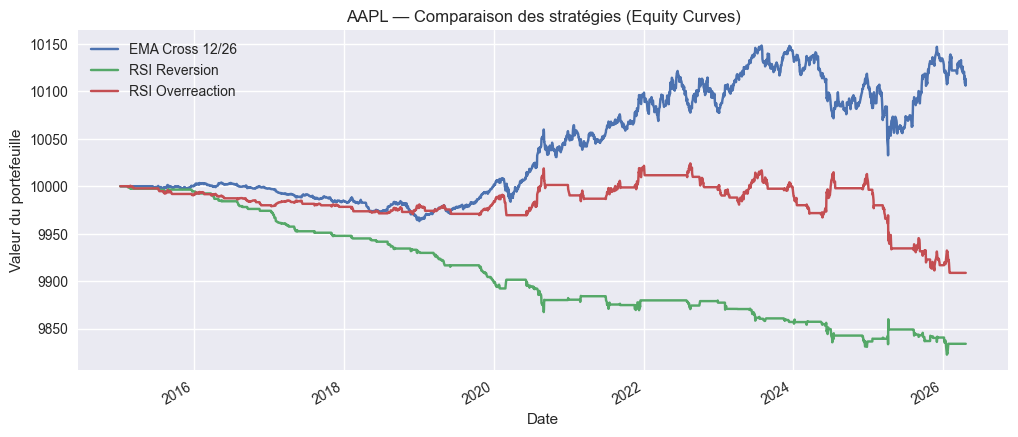

In [30]:
# Cellule 14 — Equity curves comparées

plt.figure(figsize=(12, 5))
res_ema["equity"].plot(label=res_ema["name"])
res_rsi_rev["equity"].plot(label=res_rsi_rev["name"])
res_rsi_over["equity"].plot(label=res_rsi_over["name"])
plt.title(f"{TICKER} — Comparaison des stratégies (Equity Curves)")
plt.ylabel("Valeur du portefeuille")
plt.legend()
plt.show()


## 10. Tableau comparatif des métriques

On combine les métriques des trois stratégies dans un seul tableau.


In [31]:
# Cellule 15 — Tableau comparatif des métriques

rows = []

for res in [res_ema, res_rsi_rev, res_rsi_over]:
    m = res["metrics"].copy()
    m["strategy"] = res["name"]
    rows.append(m)

df_metrics = pd.DataFrame(rows).set_index("strategy")
df_metrics


,total_return,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,max_drawdown,calmar_ratio,num_trades,win_rate,profit_factor,avg_win,avg_loss,expectancy,avg_duration
strategy,,,,,,,,,,,,,,
EMA Cross 12/26,0.010621,0.000938,0.003603,0.260208,0.314136,-0.011389,0.082327,16,0.500000,2.958276,29.006168,-9.805093,9.600537,239 days 10:30:00
RSI Reversion,-0.016594,-0.001483,0.001548,-0.957997,-0.675379,-0.017737,-0.083623,103,0.543689,1.403322,2.216173,-1.881640,0.346297,6 days 05:21:33.203883495
RSI Overreaction,-0.009125,-0.000813,0.002252,-0.360899,-0.263749,-0.011502,-0.070664,44,0.409091,0.969852,7.894066,-5.635008,-0.100387,38 days 04:54:32.727272727


## 11. Visualisation rapide de quelques métriques clés

On trace par exemple :

- Sharpe ratio
- Sortino ratio
- Max drawdown
- Annualized return


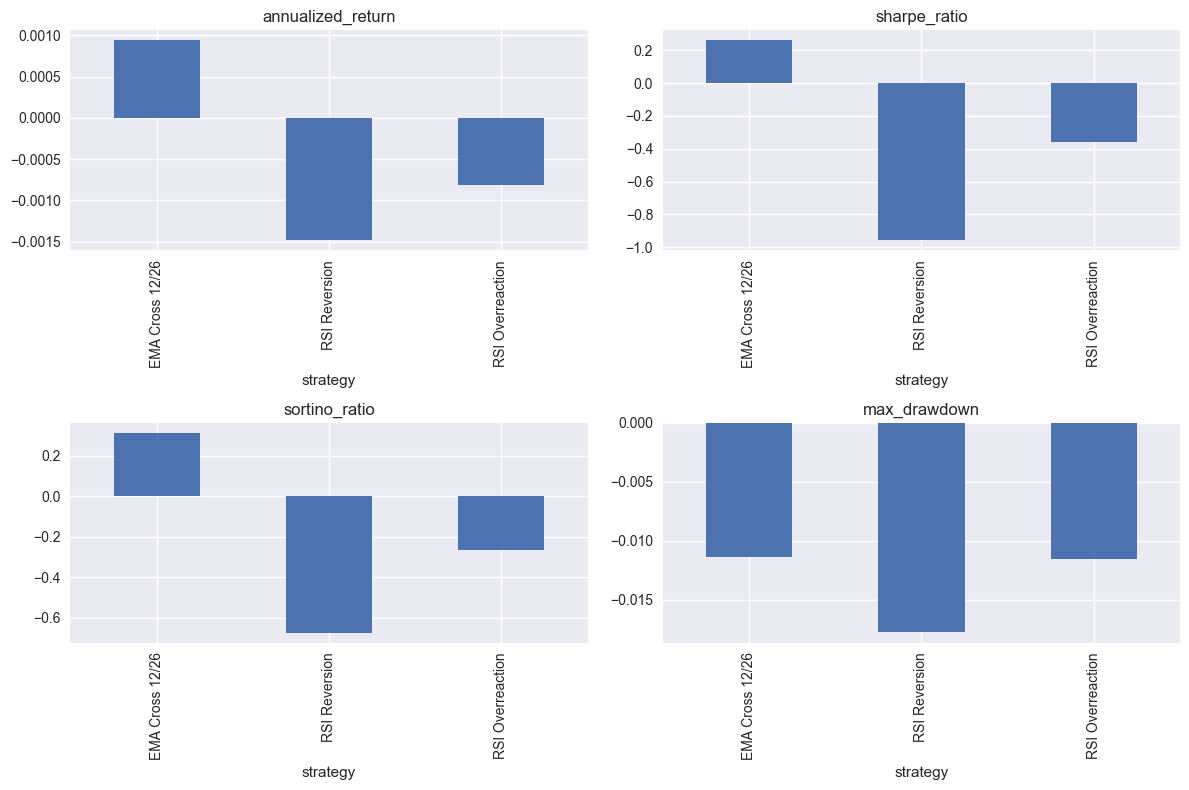

In [32]:
# Cellule 16 — Barplots de métriques

metrics_to_plot = ["annualized_return", "sharpe_ratio", "sortino_ratio", "max_drawdown"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, metric in zip(axes, metrics_to_plot):
    df_metrics[metric].plot(kind="bar", ax=ax)
    ax.set_title(metric)
    ax.grid(True, axis="y")

plt.tight_layout()
plt.show()


## 12. Analyse des trades d’une stratégie (ex : EMA)

On regarde :

- distribution des PnL
- durée moyenne des trades
- win rate, profit factor, etc.


In [33]:
# Cellule 17 — Analyse des trades EMA

trades_ema = res_ema["trades"]
trades_ema.head()


,entry_date,entry_price,exit_date,exit_price,pnl,return_trade,duration,direction
0,2015-06-15,28.150907,2015-07-23,28.184497,-0.039223,-0.001393,38 days,short
1,2015-07-27,27.478940,2018-03-27,40.810257,-13.338146,-0.485395,974 days,short
2,2018-04-17,41.470538,2018-04-23,39.185000,-2.293604,-0.055307,6 days,long
3,2018-04-24,38.912545,2018-05-03,41.327214,-2.422692,-0.062260,9 days,short
4,2018-05-07,43.512458,2020-10-02,109.579287,66.051519,1.517991,879 days,long


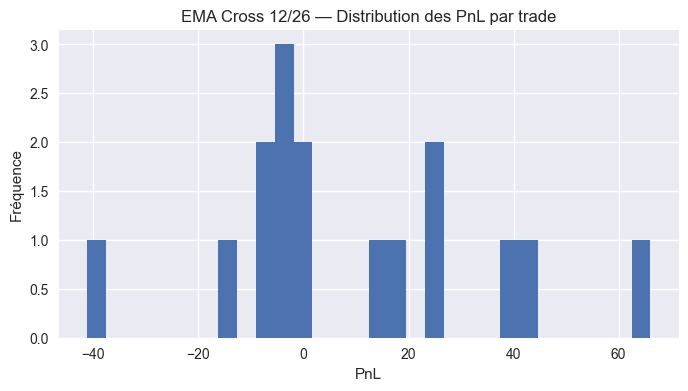

In [34]:
# Cellule 18 — Histogramme des PnL

plt.figure(figsize=(8,4))
trades_ema["pnl"].hist(bins=30)
plt.title(f"{res_ema['name']} — Distribution des PnL par trade")
plt.xlabel("PnL")
plt.ylabel("Fréquence")
plt.show()


In [35]:
# Cellule 19 — Statistiques descriptives des trades

trades_ema[["pnl", "return_trade", "duration"]].describe()


,pnl,return_trade,duration
count,16.000000,16.000000,16
mean,9.600537,0.102602,239 days 10:30:00
std,25.865972,0.419795,302 days 16:45:33.359351036
min,-41.238950,-0.485395,6 days 00:00:00
25%,-4.518120,-0.051455,31 days 12:00:00
50%,0.566552,0.002452,131 days 00:00:00
75%,25.543064,0.160298,258 days 12:00:00
max,66.051519,1.517991,974 days 00:00:00


## 13. Extension possible : multi‑actifs

On peut facilement étendre ce notebook pour :

- boucler sur une liste de tickers
- appliquer une stratégie donnée
- comparer les métriques par actif

(la logique est la même, il suffit de mettre la boucle sur les tickers).


# Conclusion

Ce notebook montre l’utilisation **complète** du framework :

- Régimes de marché (volatilité, tendance, range, impulsion) avec visualisations colorées
- Scanner d’un marché via `analyze_single_market`
- Application de plusieurs stratégies (EMA, RSI)
- Backtests réalistes avec `execute_trades` et `extract_trades`
- Métriques complètes via `compute_all_metrics`
- Comparaison visuelle et tabulaire des stratégies

Tu peux maintenant t’en servir comme **vitrine pédagogique** dans ton repo GitHub et le mentionner directement dans ta candidature.
